In [1]:
import torch as t
from utils import DataManager
import random
import matplotlib.pyplot as plt
import random
from probes import LRProbe, MMProbe, CCSProbe
import configparser
import json

In [62]:
# hyperparameters
model = 'llama-3.2-3B'
split = 0.8
device = 'cuda:0' if t.cuda.is_available() else 'cpu'

config = configparser.ConfigParser()
config.read('config.ini')
layer = eval(config[model]['probe_layer'])
noperiod = eval(config[model]['noperiod'])

# Reproducing generalization matrix

In [63]:
train_medlies  = [
    ['cities'],
    ['cities', 'neg_cities'],
    ['larger_than'],
    ['larger_than', 'smaller_than'],
    ['likely']
]

val_datasets = [
    'cities',
    'neg_cities',
    'larger_than',
    'smaller_than',
    'sp_en_trans',
    'neg_sp_en_trans',
    # 'cities_cities_conj',
    # 'cities_cities_disj',
    # 'companies_true_false',
    # 'common_claim_true_false',
    # 'counterfact_true_false'    
]

def to_str(l):
    return '+'.join(l)

seed = random.randint(0, 10000)

In [64]:
ProbeClasses = [
    LRProbe, 
    MMProbe, 
    ]

accs = {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses}

for ProbeClass in ProbeClasses:
    for medley in train_medlies:

        # set up data
        dm = DataManager()
        for dataset in medley:
            dm.add_dataset(dataset, model, layer, split=split, seed=seed, noperiod=noperiod, center=True, device=device)
        for dataset in val_datasets:
            if dataset not in medley:
                dm.add_dataset(dataset, model, layer, split=None, noperiod=noperiod, center=True, device=device)

        # train probe
        train_acts, train_labels = dm.get('train')
        probe = ProbeClass.from_data(train_acts, train_labels, device=device)
        direction = probe.direction

        # evaluate
        val_preds = []
        for val_dataset in val_datasets:
            if val_dataset in medley:
                acts, labels = dm.data['val'][val_dataset]
                accs[str(ProbeClass)][to_str(medley)][val_dataset] = (
                    probe.pred(acts, iid=True) == labels
                ).float().mean().item()
                val_preds.append((probe.pred(acts, iid=True) == labels).float())
            else:
                acts, labels = dm.data[val_dataset]
                accs[str(ProbeClass)][to_str(medley)][val_dataset] = (
                    probe.pred(acts, iid=False) == labels
                ).float().mean().item()
                val_preds.append((probe.pred(acts, iid=False) == labels).float())
        accs[str(ProbeClass)][to_str(medley)]['overall_test_acc'] = t.cat(val_preds, dim=0).mean().item()


lr_mm_accs = accs.copy()

with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

for ProbeClass in ProbeClasses:
    out = accs[str(ProbeClass)]
    out['model'] = model
    out['probe'] = ProbeClass.__str__()
    out['layer'] = layer
    out['oracle'] = False
    out['noperiod'] = noperiod
    outs.append(out)

with open('experimental_outputs/generalization_results.json', 'w') as f:
    json.dump(outs, f, indent=2)

In [65]:
import json
import pandas as pd

LAYER = 13
# load json (list of dicts)
with open("experimental_outputs/generalization_results.json", "r") as f:
    data = json.load(f)

rows = []

for entry in data[-4:]:
    # filter to layer 13
    if entry.get("layer") != LAYER:
        continue

    model = entry["model"]
    probe = entry["probe"]

    # iterate over train-set keys (dict-valued entries)
    for train_set, test_results in entry.items():
        if not isinstance(test_results, dict):
            continue  # skip metadata fields

        # avg_acc = sum(test_results.values()) / len(test_results)

        rows.append({
            "model": model,
            "probe": probe,
            "train_set": train_set,
            "avg_accuracy": test_results['overall_test_acc'],
        })

# build dataframe
df = pd.DataFrame(rows)

# pivot into table
table = df.pivot_table(
    index=["model", "probe"],
    columns="train_set",
    values="avg_accuracy",
    aggfunc="mean"
)

# optional: nicer formatting
table = table.sort_index(axis=1)
table = table.round(3)

table

train_set                      cities  cities+neg_cities  larger_than  \
model                 probe                                             
llama-3.2-3B          LRProbe   0.581              0.765        0.565   
                      MMProbe   0.735              0.807        0.632   
llama-3.2-3B-Instruct LRProbe   0.877              0.913        0.813   
                      MMProbe   0.834              0.886        0.827   

train_set                      larger_than+smaller_than  likely  
model                 probe                                      
llama-3.2-3B          LRProbe                     0.891   0.499  
                      MMProbe                     0.910   0.685  
llama-3.2-3B-Instruct LRProbe                     0.936   0.561  
                      MMProbe                     0.969   0.825

In [37]:
ccs_medlies = [
    ['cities', 'neg_cities'],
    ['larger_than', 'smaller_than'],
]

accs = {to_str(medley) : {} for medley in ccs_medlies}

for medley in ccs_medlies:
    dm = DataManager()
    for dataset in medley:
        dm.add_dataset(dataset, model, layer, split=split, seed=seed, noperiod=noperiod, center=True, device=device)
    for dataset in val_datasets:
        if dataset not in medley:
            dm.add_dataset(dataset, model, layer, split=None, noperiod=noperiod, center=True, device=device)
    
    train_acts, train_labels = dm.data['train'][medley[0]]
    train_neg_acts, _ = dm.data['train'][medley[1]]
    probe = CCSProbe.from_data(train_acts, train_neg_acts, train_labels, device=device)

    for val_dataset in val_datasets:
        if val_dataset in medley:
            acts, labels = dm.data['val'][val_dataset]
        else:
            acts, labels = dm.data[val_dataset]
        accs[to_str(medley)][val_dataset] = (
            probe.pred(acts) == labels
        ).float().mean().item()
    
ccs_accs = accs.copy()

with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

out = accs
out['model'] = model
out['probe'] = 'CCSProbe'
out['layer'] = layer
out['oracle'] = False
out['noperiod'] = noperiod
outs.append(out)

with open('experimental_outputs/generalization_results.json', 'w') as f:
    json.dump(outs, f, indent=2)

In [38]:
# get oracle probe results
oracle_accs = {str(probe_class) : {} for probe_class in ProbeClasses}
for ProbeClass in ProbeClasses:
    for dataset in val_datasets:
        dm = DataManager()
        dm.add_dataset(dataset, model, layer, split=split, noperiod=noperiod, seed=seed, device=device)
        acts, labels = dm.get('train')
        probe = ProbeClass.from_data(acts, labels, device=device)

        acts, labels = dm.data['val'][dataset]
        acc = (probe(acts, iid=True).round() == labels).float().mean().item()
        oracle_accs[str(ProbeClass)][dataset] = acc

with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

for ProbeClass in ProbeClasses:
    out = oracle_accs[str(ProbeClass)]
    out['model'] = model
    out['probe'] = ProbeClass.__str__()
    out['oracle'] = True
    out['layer'] = layer
    out['noperiod'] = noperiod
    outs.append(out)

with open('experimental_outputs/generalization_results.json', 'w') as f:
    json.dump(outs, f, indent=2)

In [39]:
models = ['llama-3.2-3B', 'llama-3.2-3B-Instruct']
ProbeClasses = [LRProbe, MMProbe, CCSProbe]

# load data
with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

accssss = {}
averagesss = {}
for model in models:
    accsss = {}
    averagess = {}
    # get LR and MM results
    for ProbeClass in [LRProbe, MMProbe]:
        accss = {}
        averages = {}
        for train_medley in train_medlies:
            for out in outs:
                if out['model'] == model and out['probe'] == ProbeClass.__str__() and out['oracle'] == False:
                    accs = out[to_str(train_medley)]
                    break
            accss[to_str(train_medley)] = accs
            average = sum(accs.values()) / len(accs)
            averages[to_str(train_medley)] = average
        accsss[ProbeClass.__str__()] = accss
        averagess[ProbeClass.__str__()] = averages

    # get CCS results
    for ProbeClass in [CCSProbe]:
        accss = {}
        averages = {}
        for train_medley in [['cities','neg_cities'], ['larger_than', 'smaller_than']]:
            for out in outs:
                if out['model'] == model and out['probe'] == ProbeClass.__str__() and out['oracle'] == False:
                    accs = out[to_str(train_medley)]
                    break
            accss[to_str(train_medley)] = accs
            average = sum(accs.values()) / len(accs)
            averages[to_str(train_medley)] = average
        accsss[ProbeClass.__str__()] = accss
        averagess[ProbeClass.__str__()] = averages
    
    # get oracle results
    for ProbeClass in ['oracle']:
        accss = {}
        for out in outs:
            if out['model'] == model and out['oracle'] == True and out['probe'] == 'LRProbe':
                accs = out
        # filter for numbers
        filtered_accs = {}
        for val_dataset in val_datasets:
            filtered_accs[val_dataset] = accs[val_dataset]
        accsss['oracle'] = filtered_accs
        averagess[ProbeClass.__str__()] = sum(filtered_accs.values()) / len(filtered_accs)

    accssss[model] = accsss
    averagesss[model] = averagess

# get few-shot results
with open('experimental_outputs/few_shot_results.json', 'r') as f:
    few_shot_results = json.load(f)
for model in models:
    few_shot_accs = {}
    for dataset in val_datasets:
        all_accs = [d['acc'] for d in few_shot_results if (d['dataset'] == dataset and d['model'] == model)]
        few_shot_accs[dataset] = max(all_accs)
    accssss[model]['few_shot'] = few_shot_accs


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

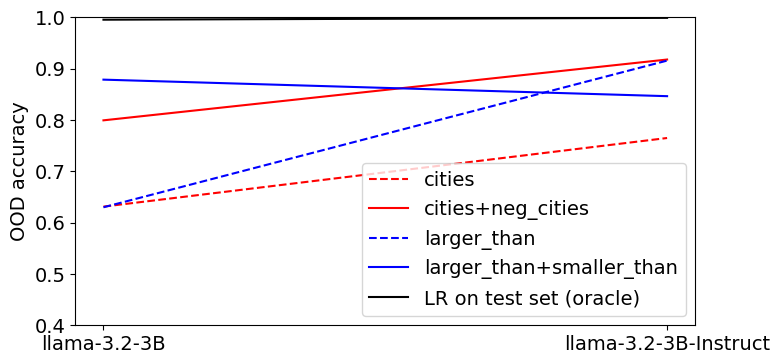

In [40]:
models = ['llama-3.2-3B', 'llama-3.2-3B-Instruct']

fig = plt.figure(figsize=(8, 4))

font = {'family' : 'Times New Roman',
        'size'   : 14}

plt.rc('font', **font)

def get_accs(full_accs, model, probe_type, medley, drop=[]):
    accs = full_accs[model][probe_type][to_str(medley)].copy()
    for d in drop:
        del accs[d]
    return accs

def get_avg(full_accs, model, probe_type, medley, drop=[]):
    accs = get_accs(full_accs, model, probe_type, medley, drop=drop)
    return sum(accs.values()) / len(accs)


plt.plot(
    [get_avg(accssss, m, 'LRProbe', ['cities'], ['cities', 'neg_cities']) for m in models], 'r--', label='cities'
)
plt.plot(
    [get_avg(accssss, m, 'LRProbe', ['cities', 'neg_cities'], ['cities', 'neg_cities']) for m in models], 'r-', label='cities+neg_cities'
)
plt.plot(
    [get_avg(accssss, m, 'LRProbe', ['larger_than'], ['larger_than', 'smaller_than']) for m in models], 'b--', label='larger_than'
)
plt.plot(
    [get_avg(accssss, m, 'LRProbe', ['larger_than', 'smaller_than'], ['larger_than', 'smaller_than']) for m in models], 'b-', label='larger_than+smaller_than'
)
plt.plot(
    [averagesss[m]['oracle'] for m in models], 'k-', label='LR on test set (oracle)'
)
# plt.plot(
#     [averagesss[f'llama-2-{scales[i]}b']['LRProbe']['likely'] for i in range(len(scales))], '-', color='gray', label='likely'
# )

# set x ticks
plt.xticks(range(len(models)), [m for m in models])

plt.ylabel('OOD accuracy')

plt.ylim(0.4, 1)
plt.legend()
# plt.savefig('junk/duplicate_generalization.pdf', bbox_inches='tight')

plt.show()




/tmp/ipykernel_22918/4072673792.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: F

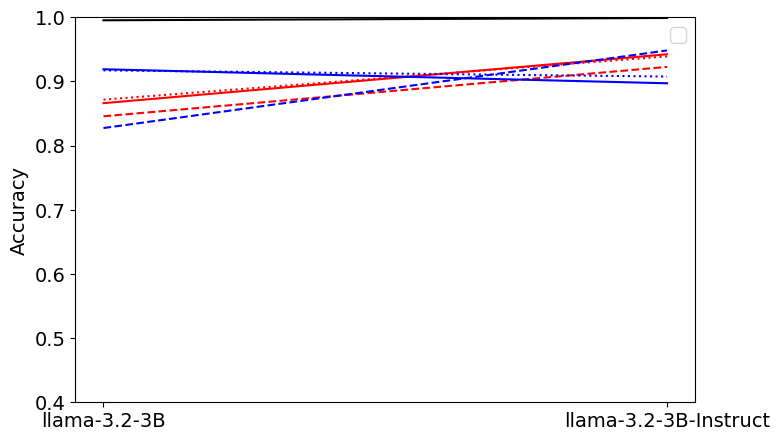

In [41]:
plt.figure(figsize=(8, 5))


plt.plot(
    [averagesss[m]['LRProbe']['cities+neg_cities'] for m in models], 'r-',
)
plt.plot(
    [averagesss[m]['MMProbe']['cities+neg_cities'] for m in models], 'r--'
)
plt.plot(
    [averagesss[m]['CCSProbe']['cities+neg_cities'] for m in models], 'r:'
)
plt.plot(
    [averagesss[m]['LRProbe']['larger_than+smaller_than'] for m in models], 'b-'
)
plt.plot(
    [averagesss[m]['MMProbe']['larger_than+smaller_than'] for m in models], 'b--'
)
plt.plot(
    [averagesss[m]['CCSProbe']['larger_than+smaller_than'] for m in models], 'b:'
)
plt.plot(
    [averagesss[m]['oracle'] for m in models], 'k-'
)
# plt.plot(
#     [averagesss[m]['LRProbe']['likely'] for m in models], '-', color='gray'
# )
# plt.plot(
#     [averagesss[m]['MMProbe']['likely'] for m in models], '--', color='gray'

# )
plt.ylim(0.4, 1)

plt.xticks(range(len(models)), [m for m in models])

plt.ylabel('Accuracy')

plt.ylim(0.4, 1)
plt.legend()
plt.show()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

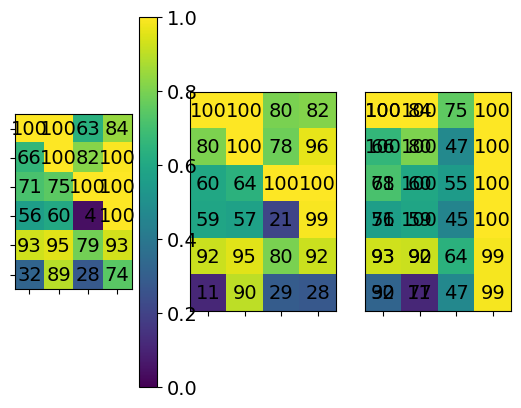

In [45]:
fig, axes = plt.subplots(1, 3)

model = 'llama-3.2-3B'

def make_axis(ax, model, probe_type, medlies):
    grid = [ [None for _ in medlies] for _ in val_datasets]
    for i, dataset in enumerate(val_datasets):
        for j, medley in enumerate(medlies):
            grid[i][j] = get_accs(accssss, model, probe_type, medley)[dataset]
    ax.imshow(grid, vmin=0, vmax=1)

    for i in range(len(grid)):
        for j in range(len(grid[0])):
            ax.text(j, i, f'{round(grid[i][j] * 100):2d}', ha='center', va='center')

    ax.set_xticks(range(len(medlies)))
    ax.set_xticklabels([])
    ax.set_yticks([])
    ax.set_yticklabels([])

make_axis(axes[0], model, 'LRProbe', [['cities'], ['cities', 'neg_cities'], ['larger_than'], ['larger_than', 'smaller_than']])

make_axis(axes[1], model, 'MMProbe', [['cities'], ['cities', 'neg_cities'], ['larger_than'], ['larger_than', 'smaller_than']])

make_axis(axes[2], model, 'CCSProbe', [['cities', 'neg_cities'], ['larger_than', 'smaller_than']])

grid = [ [None for _ in range(4)] for _ in val_datasets]
for i, dataset in enumerate(val_datasets):
    grid[i][0] = get_accs(accssss, model, 'LRProbe', ['cities'])[dataset]
    grid[i][1] = get_accs(accssss, model, 'MMProbe', ['cities'])[dataset]
    grid[i][2] = accssss[model]['few_shot'][dataset]
    grid[i][3] = accssss[model]['oracle'][dataset]
axes[2].imshow(grid, vmin=0, vmax=1)
axes[2].set_xticks(range(4))
axes[2].set_xticklabels([])
axes[2].set_yticks([])
axes[2].set_yticklabels([])

for i in range(len(grid)):
    for j in range(len(grid[0])):
        axes[2].text(j, i, f'{round(grid[i][j] * 100):2d}', ha='center', va='center')

axes[0].set_yticks(range(len(val_datasets)))
axes[0].set_yticklabels([])

# add colorbar
plt.colorbar(axes[0].images[0])

# fig.savefig('junk/llama-2-7b_generalization.pdf')
fig.show()
        